In [6]:
import pickle
import pandas as pd
import re
from collections import defaultdict, Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import torch

In [209]:
with open("/workspace/CCE_NLI/code/Abstractions/final_abstractions.pkl", 'rb') as f:
    abs_map = pickle.load(f)

In [210]:
len(abs_map)

144

In [170]:
abs_map[143]

["''",
 '-lrb-',
 '-rrb-',
 '``',
 'cc',
 'cd',
 'dt',
 'fw',
 'jj',
 'jjr',
 'jjs',
 'md',
 'nn',
 'nnp',
 'nnps',
 'nns',
 'overlap25',
 'overlap50',
 'overlap75',
 'pdt',
 'pos',
 'prp',
 'prp$',
 'rb',
 'rbr',
 'rbs',
 'rp',
 'sym',
 'uh',
 'vb',
 'vbd',
 'vbg',
 'vbn',
 'vbp',
 'vbz',
 'wdt',
 'wp',
 'wp$',
 'wrb']

In [7]:
def get_indiv_concepts(formula) -> set:
    concepts = set()
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.add(c[:end_idx])
    return concepts

def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw=[]
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        unit_concepts[unit].update(concepts)
        raw.extend(concepts)
    
    return unit_concepts, set(raw)

def build_binary_mask(neuron_mask, foundational_concept_list) -> torch.Tensor:
    num_neurons = len(neuron_mask)
    num_concepts = len(foundational_concept_list)

    # Step 1: Initialize tensor
    tensor = torch.zeros((num_neurons, num_concepts), dtype=torch.float32)

    # Step 2: Fill in ones
    for i, concepts in enumerate(neuron_mask.values()):
        for j, concept in enumerate(foundational_concept_list):
            if concept in concepts:
                tensor[i, j] = 1.0

    # Step 3: Compute row sums
    row_sums = tensor.sum(dim=1, keepdim=True)

    # Step 4: Normalize safely
    dist_tensor = torch.zeros_like(tensor)
    row_mask = (row_sums != 0).squeeze(1)  # True for rows with sum > 0
    dist_tensor[row_mask] = tensor[row_mask] #/ row_sums[row_mask]

    return dist_tensor



def get_neurons_for_cps(concepts, mapping):
    neurons = []
    for neuron, cps in mapping.items():
        for c in cps:
            if c in concepts:
                neurons.append(neuron)
                break
    return neurons

def get_all_cps_for_pi(folder):
    root_path = Path(folder)

    # Find all matching CSV files
    csv_pattern = 'Cluster*IOUS1024N.csv'
    csv_files = list(root_path.rglob(csv_pattern))
    
    concept_dict=defaultdict(lambda: defaultdict(set))
    s=set()
    for csv_file in csv_files:
        concepts = []
        csv_file = os.path.join(folder, csv_file)
        df = pd.read_csv(csv_file)
        for unit, formula in zip(df.unit, df.best_name):
            concept_dict[csv_file.split("/")[-2]][csv_file.split("/")[-1]].update(get_indiv_concepts(formula))
            s.update(get_indiv_concepts(formula))
     
      
    return concept_dict, s


In [33]:
llama_wanda_foundation=['hyp:tok:room', 'pre:tok:runs', 'pre:tok:for', 'pre:tok:ball', 'pre:tok:dogs', 'hyp:tok:race', 'pre:tok:boy', 'pre:tok:performing', 'pre:tok:cooking', 'pre:tok:hat', 'pre:tok:microphone', 'pre:tok:men', 'pre:tok:at', 'pre:tag:jj', 'pre:tag:prp$', 'pre:tok:street', 'pre:tok:jumps', 'pre:tok:red', 'hyp:tok:is', 'hyp:tok:their', 'hyp:tok:near', 'hyp:tok:talking', 'pre:tok:his', 'pre:tok:and', 'hyp:tok:running', 'hyp:tok:after', 'pre:tok:grass', 'pre:tok:through', 'hyp:tok:for', 'pre:tok:race', 'pre:tok:soccer', 'hyp:tok:asleep', 'hyp:tag:cd', 'hyp:tag:nns', 'hyp:tok:has', 'pre:tok:white', 'pre:tok:sit', 'pre:tok:outside', 'hyp:tok:dog', 'hyp:tok:swimming', 'pre:tag:vbg', 'hyp:tok:girl', 'hyp:tok:his', 'pre:tok:football', 'hyp:tag:jj', 'pre:tok:snowboarder', 'hyp:tag:in', 'pre:tok:woman', 'hyp:tok:shirt', 'pre:tok:young', 'hyp:tok:to', 'hyp:tok:at', 'hyp:tok:dogs', 'pre:tok:playing', 'hyp:tag:vbp', 'hyp:tag:rb', 'pre:tok:band', 'pre:tok:dancing', 'hyp:tok:working', 'pre:tok:girls', 'pre:tag:cd', 'hyp:tok:nobody', 'pre:tok:swimming', 'pre:tok:jumping', 'hyp:tag:vbz', 'hyp:tok:men', 'hyp:tag:ex', 'hyp:tok:black', 'hyp:tok:standing', 'pre:tag:vbz', 'hyp:tok:soccer', 'pre:tok:dog', 'pre:tok:walk', 'pre:tok:shirt', 'pre:tag:vb', 'oth:overlap:overlap50', 'pre:tok:lady', 'pre:tok:man', 'hyp:tag:cc', 'pre:tok:standing', 'hyp:tag:prp', 'hyp:tok:sleeping', 'hyp:tag:nnp', 'hyp:tok:walks', 'hyp:tag:dt', 'pre:tag:dt', 'pre:tok:park', 'pre:tok:guitar', 'pre:tok:walks', 'pre:tok:table', 'hyp:tok:bike', 'hyp:tok:woman', 'hyp:tok:smiling', 'pre:tok:in', 'pre:tok:room', 'hyp:tok:park', 'pre:tok:girl', 'pre:tok:riding', 'hyp:tok:game', 'pre:tag:nn', 'pre:tok:stage', 'hyp:tok:inside', 'pre:tok:beach', 'hyp:tag:.', 'hyp:tag:vb', 'hyp:tok:alone', 'hyp:tok:riding', 'hyp:tok:something', 'pre:tok:her', 'hyp:tok:lady', 'oth:overlap:overlap25', 'hyp:tok:girls', 'pre:tok:while', 'pre:tok:player', 'pre:tok:boys', 'hyp:tok:outdoors', 'pre:tok:book', 'hyp:tok:on', 'hyp:tok:water', 'hyp:tok:there', 'pre:tag:cc', 'hyp:tok:boys', 'pre:tag:vbp', 'pre:tok:blue', 'hyp:tok:sitting', 'hyp:tok:man', 'pre:tok:people', 'pre:tok:gentleman', 'pre:tok:wearing', 'pre:tok:talking', 'pre:tok:pool', 'pre:tag:,', 'hyp:tok:next', 'pre:tok:cellphone', 'hyp:tok:wearing', 'pre:tok:person', 'pre:tok:pink', 'pre:tok:water', 'hyp:tok:in', 'hyp:tok:nap', 'hyp:tok:walking', 'hyp:tok:tall', 'hyp:tag:vbg', 'hyp:tok:boy', 'pre:tok:to', 'pre:tok:boat', 'pre:tok:baseball', 'pre:tok:something', 'hyp:tok:sits', 'pre:tok:bike', 'pre:tok:with', 'pre:tok:male', 'hyp:tok:her', 'hyp:tok:outside', 'pre:tok:walking', 'pre:tok:sitting', 'pre:tok:kitchen', 'pre:tok:sits', 'pre:tok:game', 'hyp:tok:no', 'hyp:tok:white', 'pre:tok:working', 'pre:tag:nns', 'hyp:tok:eating', 'hyp:tok:human', 'pre:tok:child', 'pre:tok:basketball', 'hyp:tag:nn', 'pre:tok:women', 'pre:tag:in', 'hyp:tok:are', 'hyp:tok:person', 'pre:tag:.', 'pre:tok:holding', 'pre:tok:children', 'pre:tok:black', 'pre:tok:workers', 'hyp:tok:playing', 'oth:overlap:overlap75', 'hyp:tok:people', 'pre:tok:running', 'hyp:tok:women', 'hyp:tag:prp$']

wanda_few, wanda=find_abstractions(set(llama_wanda_foundation))

llama_lth_foundaiton=['pre:tok:for', 'pre:tag:nn', 'pre:tok:boy', 'hyp:tag:.', 'hyp:tag:vb', 'pre:tag:prp', 'pre:tok:is', 'oth:overlap:overlap25', 'pre:tok:her', 'hyp:tok:red', 'pre:tok:men', 'pre:tok:while', 'pre:tok:on', 'pre:tok:at', 'pre:tag:jj', 'pre:tag:prp$', 'pre:tok:street', 'pre:tok:red', 'hyp:tok:is', 'pre:tok:and', 'hyp:tok:their', 'pre:tok:his', 'hyp:tok:on', 'pre:tok:floor', 'hyp:tok:young', 'hyp:tok:there', 'pre:tok:down', 'hyp:tok:for', 'pre:tag:cc', 'hyp:tok:with', 'hyp:tok:boys', 'pre:tag:vbp', 'hyp:tag:cd', 'hyp:tag:nns', 'hyp:tok:has', 'pre:tok:blue', 'hyp:tok:sitting', 'pre:tok:people', 'hyp:tok:man', 'hyp:tok:and', 'hyp:tok:dog', 'pre:tok:wearing', 'hyp:tok:child', 'pre:tag:vbg', 'hyp:tok:girl', 'hyp:tag:jj', 'hyp:tag:in', 'pre:tok:woman', 'hyp:tok:two', 'pre:tok:young', 'hyp:tok:wearing', 'hyp:tok:to', 'hyp:tok:at', 'pre:tok:water', 'hyp:tok:in', 'hyp:tok:walking', 'pre:tok:playing', 'hyp:tag:vbp', 'hyp:tag:rb', 'hyp:tag:vbg', 'pre:tok:girls', 'pre:tag:cd', 'pre:tok:with', 'pre:tok:baseball', 'pre:tok:sitting', 'hyp:tok:outside', 'hyp:tag:vbz', 'hyp:tok:men', 'pre:tok:walking', 'hyp:tok:blue', 'hyp:tok:black', 'pre:tag:vbz', 'hyp:tok:standing', 'pre:tok:dog', 'pre:tag:nns', 'oth:overlap:overlap50', 'pre:tok:man', 'pre:tok:standing', 'hyp:tag:nn', 'pre:tok:women', 'pre:tag:in', 'hyp:tok:are', 'hyp:tok:person', 'pre:tag:.', 'pre:tok:holding', 'hyp:tag:nnp', 'hyp:tag:dt', 'pre:tag:dt', 'pre:tok:are', 'oth:overlap:overlap75', 'pre:tok:night', 'hyp:tok:people', 'pre:tok:in', 'hyp:tok:woman', 'pre:tag:vbn', 'pre:tok:girl', 'hyp:tok:women', 'hyp:tag:prp$']
lth_freq, lth= find_abstractions(set(llama_lth_foundaiton))

In [160]:


def find_cluster(raw_concept):
    for cluster in abs_map:
        if raw_concept in abs_map[cluster]:
            return cluster
def find_abstractions(expls):
    if isinstance(expls, set):
        glob = expls
    else:
        glob = set([i for j in expls.values() for i in j ])
    abstracts=[]
    exact_concepts_perabs=defaultdict(set)
    for concept in glob:
        raw_concept = concept.split(":")[-1]
        abstraction_cluster = find_cluster(raw_concept)
        if abstraction_cluster==143: 
            continue
        if not abstraction_cluster:abstraction_cluster=150
        exact_concepts_perabs[abstraction_cluster].add(raw_concept)
        
        abstracts.append(abstraction_cluster)
    return Counter(abstracts), set(abstracts), exact_concepts_perabs


In [ ]:
abstraction_cluster

In [21]:
import numpy as np

a = np.random.rand(4,)
b = np.random.rand(3,4)

result=(b*a).reshape(-1)

print(b,a,result.shape)


[[0.97406051 0.90112898 0.83070331 0.16884562]
 [0.21531804 0.526382   0.0651335  0.12565775]
 [0.40981651 0.22458697 0.7272159  0.08520645]] [0.78037882 0.72187568 0.99061213 0.27732407] (12,)


In [201]:
all_models_all_methods_ious=defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict())))
validruns=defaultdict(lambda: defaultdict(int))
models=['BERT', 'LLAMA']

methods=['CoFi', 'lottery_ticket'] #'wanda', 'CoFi',
freqss={}
for model in models:
    for method in methods:
        print("+========", method)
        valid_runs=0
        for fname in range(5,6):
            try:
                cluster_to_concepts, set_all_concepts = get_all_cps_for_pi(f'/workspace/CCE_NLI/{model}/exp/{method}/Run0.25_{fname}/Expls/')
                cluster_to_concepts_pt, set_all_concepts_pt = get_all_cps_for_pi(f'/workspace/CCE_NLI/{model}/exp/pretrained/Expls/')
               
                if not cluster_to_concepts:
                    break
                if fname==5:
                    dense = cluster_to_concepts['0.0%Pruned']
                    pt = cluster_to_concepts_pt['Expls']
                    freq_dense, dense_abs,_=find_abstractions(dense)
                    freq_pt, abs_pt,_=find_abstractions(pt)
                    print(freq_dense)
                start=0
                for sparsity in sorted(cluster_to_concepts):
                    if sparsity == '0.0%Pruned': continue
     
                    sparse = cluster_to_concepts[sparsity]
                    frequency, sparse_abs,_ = find_abstractions(sparse)
                    freqss[sparsity]=frequency
                    iou=len(sparse_abs&abs_pt&dense_abs)/len(sparse_abs)
                    
                    print(f"concepts common to sparse, dense, pretrained {len(dense_abs&sparse_abs&abs_pt)/len(sparse_abs)}")
                    print(f"concepts common to sparse, dense, pretrained {sorted(list(dense_abs&sparse_abs&abs_pt))[:10]}")
                    print(f"concepts common to dense, pretrained {len(dense_abs & abs_pt)}")

                    print(f"concepts between sparse and (dense that are not in pretrained) = {len(sparse_abs & (dense_abs - abs_pt))/len(sparse_abs)}")
                    print(f"concets in dense not in pretrained {len(dense_abs - abs_pt)}")

                    print(f"concepts between sparse and (pretrained that are not in dense) = {len(sparse_abs & (abs_pt - dense_abs))}")
                    print(f"num SPARSE concepts = {len(sparse_abs)}")
        
                    if 'iou' not in all_models_all_methods_ious[model][method][start]:
                        all_models_all_methods_ious[model][method][start]['iou'] =iou
                        
                    else:
                        all_models_all_methods_ious[model][method][start]['iou'] +=iou
                    if 'overlap' not in all_models_all_methods_ious[model][method][start]:
                        all_models_all_methods_ious[model][method][start]['overlap'] =[len(sparse_abs&dense_abs)]
                        
                    else:
                        all_models_all_methods_ious[model][method][start]['overlap'].append(len(sparse_abs&dense_abs))
                    start+=1
                valid_runs+=1

            except Exception as e:
                print(e)

        validruns[model][method] = valid_runs
pi={0:0.0, 1:25.0, 2:43.75, 3:57.81, 4:68.36, 5:76.27, 6:82.03}
for mod, method_ in all_models_all_methods_ious.items():
    r=0
    for m, sparsity in method_.items():
        for s,iou in sparsity.items():
            all_models_all_methods_ious[mod][m][s]['iou']  /= validruns[mod][m]     
        r+=1
#rename x axis 
for mod, method_ in all_models_all_methods_ious.items():
    for m, sparsity in method_.items():
        print(list(sparsity.keys()))
        for s in list(sparsity.keys()):  # list() creates a copy so looping over old version
            all_models_all_methods_ious[mod][m][pi[s]] = sparsity.pop(s)

'''25.0: 0.8627450980392157,
                                       43.75: 0.8380952380952381,
                                       57.81: 0.8301886792452831,
                                       68.36: 0.7647058823529411,
                                       76.27: 0.6601941747572816}),'''
all_models_all_methods_ious

+======== CoFi
concepts common to sparse, dense, pretrained 0.7407407407407407
concepts common to sparse, dense, pretrained [1, 2, 6, 9, 10, 11, 12, 13, 14, 15]
concepts common to dense, pretrained 80
concepts between sparse and (dense that are not in pretrained) = 0.18518518518518517
concets in dense not in pretrained 25
concepts between sparse and (pretrained that are not in dense) = 3
num SPARSE concepts = 108
concepts common to sparse, dense, pretrained 0.7247706422018348
concepts common to sparse, dense, pretrained [1, 2, 6, 9, 10, 11, 12, 13, 14, 15]
concepts common to dense, pretrained 80
concepts between sparse and (dense that are not in pretrained) = 0.1834862385321101
concets in dense not in pretrained 25
concepts between sparse and (pretrained that are not in dense) = 4
num SPARSE concepts = 109
concepts common to sparse, dense, pretrained 0.7403846153846154
concepts common to sparse, dense, pretrained [1, 2, 6, 9, 10, 11, 12, 13, 14, 15]
concepts common to dense, pretrained

defaultdict(<function __main__.<lambda>()>,
            {'BERT': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'CoFi': defaultdict(<function __main__.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                      {0.0: defaultdict(None,
                                                   {'iou': 0.7407407407407407,
                                                    'overlap': [100]}),
                                       25.0: defaultdict(None,
                                                   {'iou': 0.7247706422018348,
                                                    'overlap': [99]}),
                                       43.75: defaultdict(None,
                                                   {'iou': 0.7403846153846154,
                                                    'overlap': [97]}),
                                       57.81: defaultdict(None,
                                                   {'io

In [211]:
dense

defaultdict(set,
            {'Cluster1IOUS1024N.csv': {'hyp:tag:.',
              'hyp:tag:cc',
              'hyp:tag:cd',
              'hyp:tag:dt',
              'hyp:tag:in',
              'hyp:tag:jj',
              'hyp:tag:nn',
              'hyp:tag:nnp',
              'hyp:tag:nns',
              'hyp:tag:prp',
              'hyp:tag:prp$',
              'hyp:tag:rb',
              'hyp:tag:vb',
              'hyp:tag:vbg',
              'hyp:tag:vbn',
              'hyp:tag:vbp',
              'hyp:tag:vbz',
              'hyp:tok:and',
              'hyp:tok:are',
              'hyp:tok:at',
              'hyp:tok:basketball',
              'hyp:tok:beach',
              'hyp:tok:bike',
              'hyp:tok:blue',
              'hyp:tok:boy',
              'hyp:tok:boys',
              'hyp:tok:by',
              'hyp:tok:dog',
              'hyp:tok:dogs',
              'hyp:tok:driving',
              'hyp:tok:for',
              'hyp:tok:girl',
              'hyp:tok:

{'0.25267370011269075%Pruned': {5: 1, 110: 1, 93: 1, 4: 1, 131: 1, 117: 1, 39: 1, 41: 1}}
{'0.25267370011269075%Pruned': {5: 1, 110: 1, 93: 1, 4: 1, 131: 1, 117: 1, 39: 1, 41: 1}, '0.4443280775114645%Pruned': {71: 2, 30: 1, 93: 1, 86: 1, 4: 1, 131: 1, 117: 2, 39: 1, 41: 1, 55: 1}}
{'0.25267370011269075%Pruned': {5: 1, 110: 1, 93: 1, 4: 1, 131: 1, 117: 1, 39: 1, 41: 1}, '0.4443280775114645%Pruned': {71: 2, 30: 1, 93: 1, 86: 1, 4: 1, 131: 1, 117: 2, 39: 1, 41: 1, 55: 1}, '0.5826748728764346%Pruned': {71: 1, 93: 1, 4: 1, 126: 1, 55: 1, 131: 1, 41: 1}}
{'0.25267370011269075%Pruned': {5: 1, 110: 1, 93: 1, 4: 1, 131: 1, 117: 1, 39: 1, 41: 1}, '0.4443280775114645%Pruned': {71: 2, 30: 1, 93: 1, 86: 1, 4: 1, 131: 1, 117: 2, 39: 1, 41: 1, 55: 1}, '0.5826748728764346%Pruned': {71: 1, 93: 1, 4: 1, 126: 1, 55: 1, 131: 1, 41: 1}, '0.6841850626856109%Pruned': {71: 1, 4: 1, 126: 1, 29: 1, 7: 1, 41: 1, 117: 3}}
{'0.25267370011269075%Pruned': {5: 1, 110: 1, 93: 1, 4: 1, 131: 1, 117: 1, 39: 1, 41: 1}, '0

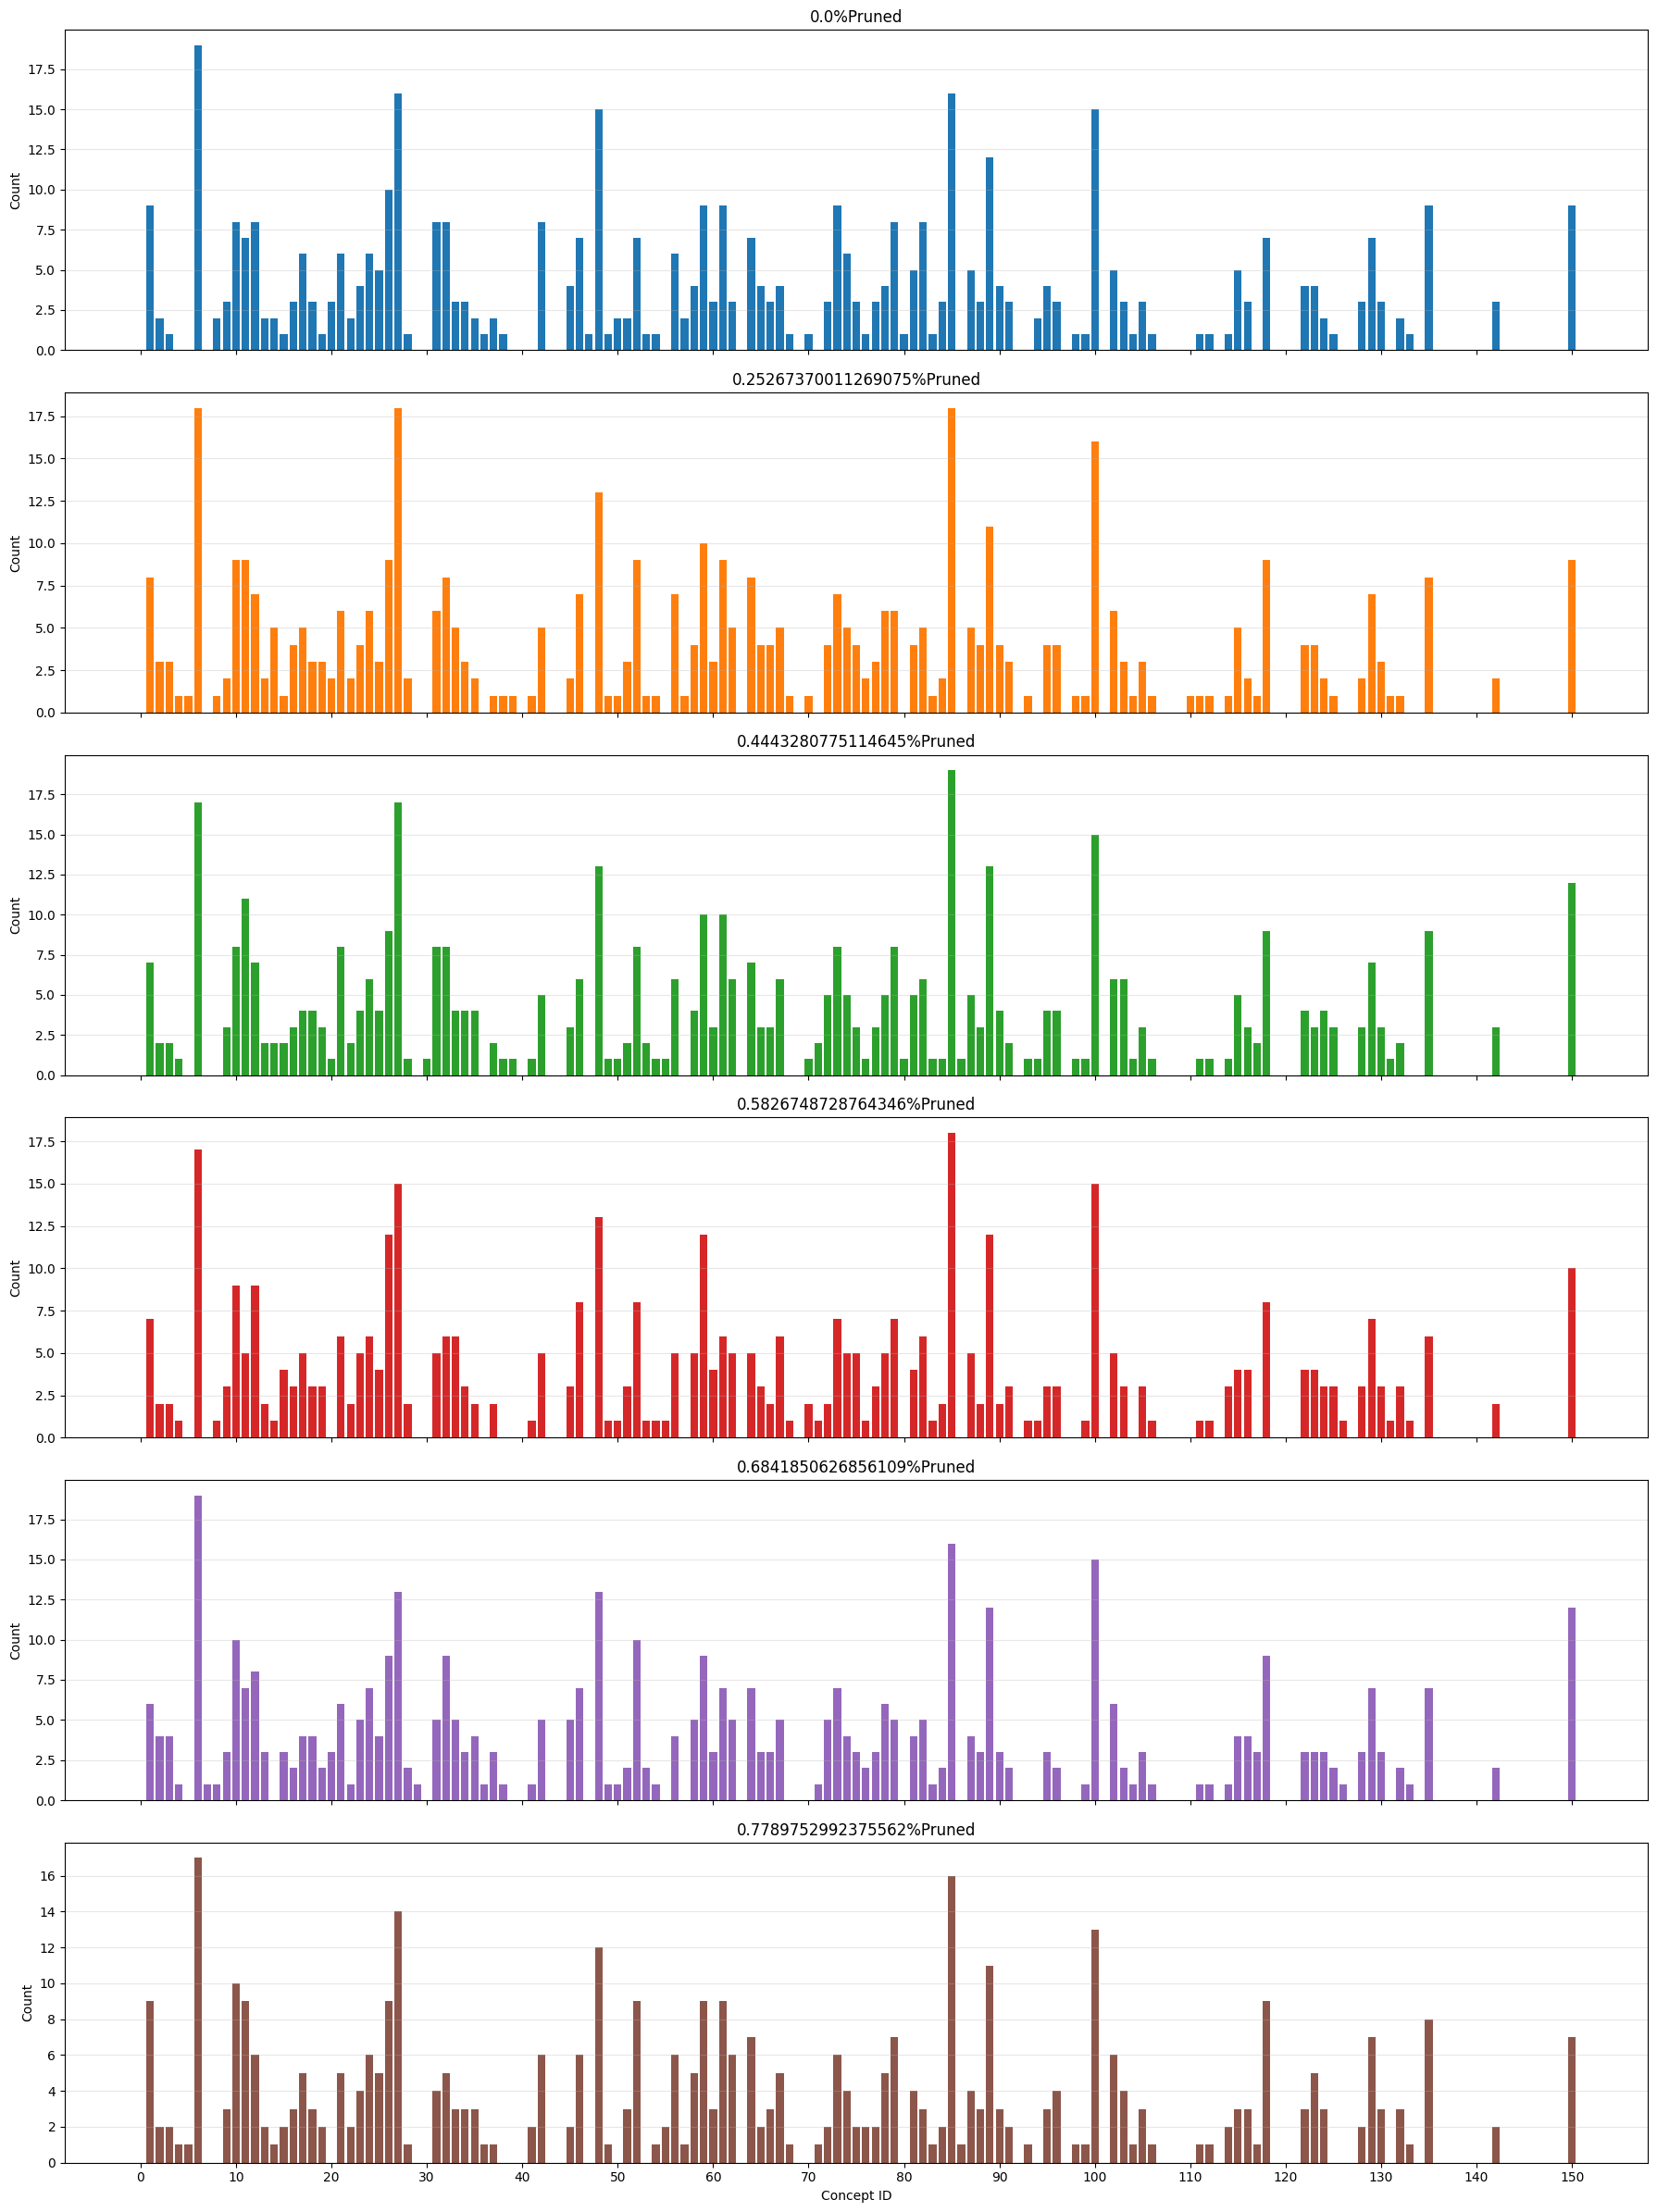

In [197]:
import matplotlib.pyplot as plt
import numpy as np

def plot_counters(data: dict, x_max: int = 150):
    """
    data: dict of {label: Counter/dict}
    x_max: upper bound of x axis
    """
    n = len(data)
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(n, 1, figsize=(18, 4 * n), sharex=True)
    if n == 1:
        axes = [axes]

    x = np.arange(0, x_max + 1)

    for ax, (label, counter), color in zip(axes, data.items(), colors):
        y = np.array([counter.get(i, 0) for i in x])
        ax.bar(x, y, color=color, width=0.8)
        ax.set_title(label, fontsize=12)
        ax.set_ylabel('Count')
        ax.grid(axis='y', alpha=0.3)

    axes[-1].set_xlabel('Concept ID')
    plt.xticks(np.arange(0, x_max + 1, 10))
    plt.tight_layout()
    
    plt.show()


# --- example usage ---
if __name__ == '__main__':
    base=freqss['0.0%Pruned']
    new={}
    old={}
    for k in freqss:
        if k == '0.0%Pruned': 
            new[k]=base
            continue
        new[k] = {j:v for j,v in freqss[k].items() if j in base}
        old[k]= {j:v for j,v in freqss[k].items() if j not in base}
        print(old)
    plot_counters(freqss)

In [142]:
all_models_all_methods_ious=defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
validruns=defaultdict(lambda: defaultdict(int))
models=['LLAMA', 'BERT', 'BOWMAN']

methods=['CoFi','lottery_ticket', 'wanda']
for model in models:
    for method in methods:
        valid_runs=0
        dense_abstractions = []
        for fname in range(5,6):

            cluster_to_concepts, set_all_concepts = get_all_cps_for_pi(f'/workspace/CCE_NLI/{model}/exp/{method}/Run0.25_{fname}/Expls/')
            cluster_to_concepts_pt, set_all_concepts_pt = get_all_cps_for_pi(f'/workspace/CCE_NLI/{model}/exp/pretrained/Expls/')

            if not cluster_to_concepts:
                break
            if fname==5:
                #dense = cluster_to_concepts['0.0%Pruned']
                dense = cluster_to_concepts_pt['Expls']
                
                for cluster in dense:
                    freq_dense, dense_abs, _=find_abstractions(dense[cluster])
                    
                    dense_abstractions.append(dense_abs)
            if not len(dense_abstractions) == 3: continue
    
            start=0
            for sparsity in sorted(cluster_to_concepts):
                sparse_abstractions = []
                #if sparsity == '0.0%Pruned': continue

                sparse = cluster_to_concepts[sparsity]

                if len(sparse)!=3:continue
                for cluster in sparse:
                    frequency, sparse_abs, _ = find_abstractions(sparse[cluster])
                    sparse_abstractions.append(sparse_abs)
                
                #get the iou for eahc index
                assert len(sparse_abstractions) == len(dense_abstractions), f"{len(sparse_abstractions)} != {len(dense_abstractions)}"
                iou= [f"{len(s&d)}/ {len(s|d)} = {len(s&d)/len(s|d)}" for s,d in zip(sparse_abstractions, dense_abstractions)]

                #add the lists 
                if all_models_all_methods_ious[model][method][start] :
                    all_models_all_methods_ious[model][method][start] = [a + b for a, b in zip(all_models_all_methods_ious[model][method][start], iou)]
                else:
                    all_models_all_methods_ious[model][method][start]  = iou
                start+=1
            valid_runs+=1
           

        validruns[model][method] = valid_runs
        validruns['LLAMA']['lottery_ticket'] = 1

pi={0:0.0, 1:25.0, 2:43.75, 3:57.81, 4:68.36, 5:76.27, 6:82.03}
for mod, method_ in all_models_all_methods_ious.items():
    r=0
    for m, sparsity in method_.items():
        for s,iou in sparsity.items():
            all_models_all_methods_ious[mod][m][s]  = [a  for a in  all_models_all_methods_ious[mod][m][s]]
            
        r+=1
#rename x axis 
for mod, method_ in all_models_all_methods_ious.items():
    for m, sparsity in method_.items():
        for s in list(sparsity.keys()):  # list() creates a copy so looping over old version
            all_models_all_methods_ious[mod][m][pi[s]] = sparsity.pop(s)
all_models_all_methods_ious

defaultdict(<function __main__.<lambda>()>,
            {'LLAMA': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'lottery_ticket': defaultdict(list,
                                      {0.0: ['45/ 78 = 0.5769230769230769',
                                        '52/ 84 = 0.6190476190476191',
                                        '79/ 112 = 0.7053571428571429'],
                                       25.0: ['35/ 74 = 0.47297297297297297',
                                        '49/ 81 = 0.6049382716049383',
                                        '80/ 115 = 0.6956521739130435'],
                                       43.75: ['38/ 75 = 0.5066666666666667',
                                        '52/ 87 = 0.5977011494252874',
                                        '83/ 114 = 0.7280701754385965'],
                                       57.81: ['32/ 75 = 0.4266666666666667',
                                        '47/ 82 = 0.573170731707317'

In [162]:
header = f"{'Model':<20} {'Method':<20} {'Abstraction':<20} {'Avg length difference between frequency of sparse and abs common:':<20} {'Percent of sparse concepts common with dense  in abstracriion':>8} {'# abs that overlap':>8}"
print(header)
print("-" * len(header))
methods_ious=defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
models=['']
for model in models:
    for method in methods:
        dense_abstractions = []
        for fname in range(5, 8):
            
            cluster_to_concepts, set_all_concepts = get_all_cps_for_pi(f'/workspace/CCE_NLI/{model}/exp/{method}/Run0.25_{fname}/Expls/')
            cluster_to_concepts_pt, set_all_concepts_pt = get_all_cps_for_pi(f'/workspace/CCE_NLI/{model}/exp/pretrained/Expls/')

            if not cluster_to_concepts:
                break
            if fname==5:
                #dense = cluster_to_concepts['0.0%Pruned']
                dense = cluster_to_concepts_pt['Expls']

            freq_dense, dense_abs, exact_dense_cps = find_abstractions(dense)
   
            if len(dense_abs)==0:

                continue

            start = 0
            for sparsity in sorted(cluster_to_concepts):
                #if sparsity == '0.0%Pruned':continue

                sparse = cluster_to_concepts[sparsity]
                frequency, sparse_abs, exact_sparse_cps = find_abstractions(sparse)
              
                iou = len(sparse_abs & dense_abs) / len(dense_abs | sparse_abs)
                
                all_models_all_methods_ious[model][method][start] += (
                    len(sparse_abs & dense_abs) / len(dense_abs)
                )
                diff=0
                for common_abs in sparse_abs & dense_abs:
                    diff += abs(frequency[common_abs]- freq_dense[common_abs])
                
                
                over=0
                sparsity_val = float(sparsity.replace('%Pruned', ''))
                for common in sparse_abs & dense_abs:
                    over += len(exact_dense_cps[common] & exact_sparse_cps[common]) / len(exact_dense_cps[common])
                print(
                    f"{model:<20} {method:<20} {sparsity_val:<20.2f}"
                    f"{diff/len(sparse_abs & dense_abs):<80}"
                    f'{over/len(sparse_abs & dense_abs):<50}'
                    f'{len(sparse_abs & dense_abs)}/{len(dense_abs | sparse_abs)}'
                

                )
                print(sorted(dense_abs-sparse_abs))
            print("-------------------------")

               #o wuth the abstractions that are preeserved there is a decreased iverlap of concepts but still hig even in wanda (but at 76 the acc is eaningless so this high alignment between sparse and denes for all common abs is weird)

Model                Method               Abstraction          Avg length difference between frequency of sparse and abs common: Percent of sparse concepts common with dense  in abstracriion # abs that overlap
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
LLAMA                wanda                0.00                1.8275862068965518                                                              0.6156382251209837                                87/113
[7, 8, 28, 49, 55, 57, 69, 72, 80, 83, 86, 104, 107, 125, 126, 131, 139]
LLAMA                wanda                25.00               1.8837209302325582                                                              0.5868770118770118                                86/112
[4, 7, 14, 36, 49, 50, 55, 69, 80, 83, 86, 91, 104, 107, 125, 126, 131, 139]
LLAMA                wanda      

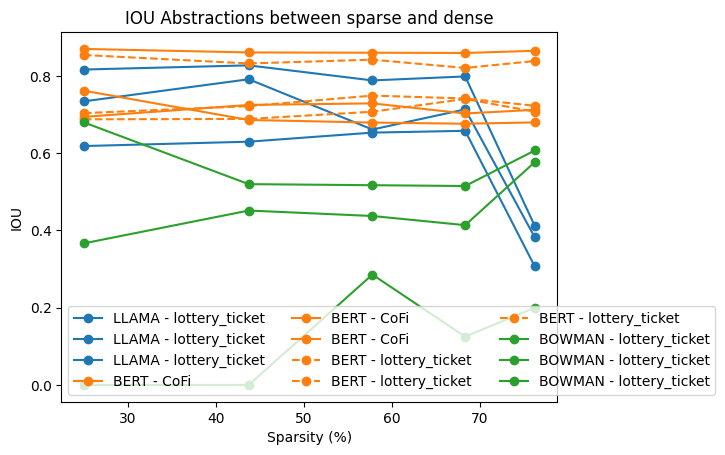

In [260]:
colors = plt.cm.tab10.colors
linestyles = ['-', '--', ':']

model_colors = {model: colors[i] for i, model in enumerate(all_models_all_methods_ious.keys())}

plt.figure()

for model, methods in all_models_all_methods_ious.items():
    for j, (method, vals) in enumerate(methods.items()):
        sparsity = [float(k) for k in vals.keys()]
        scores = list(vals.values())
        sparsity, scores = zip(*sorted(zip(sparsity, scores)))

        plt.plot(
            sparsity,
            scores,
            marker='o',
            color=model_colors[model],
            linestyle=linestyles[j],
            label=f"{model} - {method}"
        )
plt.title('IOU Abstractions between sparse and dense')
plt.xlabel("Sparsity (%)")
plt.ylabel("IOU")
plt.legend(ncol=3)
plt.show()
